# D207 Exploratory Data Analysis Performance Assessment

D207 Performance Assessment 
<br> 
Exploratory Data Analysis
<br> 
Instructor: Dr. William Sewell
<br> 
Student Name: Devon E. Johnson
<br> 
Student ID: 011494484
<br> 
Email: djo3593@wgu.edu
<br> 

### Table of Contents

* [A1: Research Question](#A1:-Research-Question)
* [A2: Benefits of Research Question](#A2:-Benefits-of-Research-Question)
* [A3: Relevant Data Identification](#A3:-Relevant-Data-Identification)
* [A4: Data Re-Cleaning](#A4:-Data-Re-Cleaning)
* [B1: Statistical Analysis](#B1:-Statistical-Analysis)
* [B2: Outcome of Statistical Analysis](#B2:-Outcome-of-Statistical-Analysis)
* [B3: Justification of Statistical Analysis](#B3:-Justification-of-Statistical-Analysis)
* [C: Univariate Analysis](#C:-Univariate-Analysis)
* [D: Bivariate Analysis](#D:-Bivariate-Analysis)
* [E1: Results of Hypothesis Test](#E1:-Results-of-Hypothesis-Test)
* [E2: Limitations of Data Analysis](#E2:-Limitations-of-Data-Analysis)
* [E3: Recommended Course of Action](#E3:-Recommended-Course-of-Action)
* [F: Panopto Recording](#F:-Panopto-Recording)
* [G: Code References](#G:-Code-References)
* [H: Source References](#H:-Source-References)

## A1: Research Question

In an effort to build on my last performance assessment in D206 I will now narrow my research question to investigate specific potential variables behind patient readmission. 

__Research Question__: "Are overweight patients more likely to be readmitted?" 
<br>

## A2: Benefits of Research Question

Medical infrastructure is often over-taxed by too many patients and too few doctors to provide quality and timely care. Addressing potential factors that contribute to patient re-admittance could result in a reduction or easier distribution of overall patient numbers, thus reducing this load. If patients above a certain BMI are assessed to be more at risk of readmittance, then doctors/clinics might consider incorporating more treatments designed to return patients to health body weights, e.g. nutritionist referrals, physical therapy, medications, etc, in conjunction with the treatment for whatever present ailment for which they intended to receive care. 

## A3: Relevant Data Identification

The relevant variables for this research question are:

__readmis_within_month (Example: No)__
Data Dictionary Description: Whether the patient was readmitted within a month of release or not: yes, no
Variable Type: Categorical/Nominal
Datatype Property: object

__overweight (Example: 1)__
Data Dictionary Description: Whether the patient is considered overweight based on age, gender, and height: yes, no
Variable Type: Categorical/Nominal
Datatype Property: float64

## A4: Data Re-Cleaning

In [2]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\My Name Devon\OneDrive\Documents\WGU MSDA\D207\medical_clean.csv'
df = pd.read_csv(file_path, index_col = 0)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_id         10000 non-null  object 
 1   Interaction         10000 non-null  object 
 2   UID                 10000 non-null  object 
 3   City                10000 non-null  object 
 4   State               10000 non-null  object 
 5   County              10000 non-null  object 
 6   Zip                 10000 non-null  int64  
 7   Lat                 10000 non-null  float64
 8   Lng                 10000 non-null  float64
 9   Population          10000 non-null  int64  
 10  Area                10000 non-null  object 
 11  TimeZone            10000 non-null  object 
 12  Job                 10000 non-null  object 
 13  Children            10000 non-null  int64  
 14  Age                 10000 non-null  int64  
 15  Income              10000 non-null  float64
 16  Marital  

In [3]:
#Code for Fixing Naming Conventions/Missleading Labels
new_columns = ["customer_id", "interaction", "uid", "city", "state", "county", 
                    "zip", "latitude", "longitude", "population", "area", "timezone", "job", "children_in_household", 
                    "age", "sponsor_income", "marital_status", "gender", "readmis_within_month", 
                    "vitd_lvl", "pcm_visits", "hosp_meals_eaten", "vitd_supp", "soft_drink_consumption", "initial_admin", 
                    "high_blood_pressure", "stroke", "complication_risk", "overweight", "arthritis", "diabetes", "hyperlipidemia", 
                    "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "services", 
                    "initial_stay", "est_daily_charge", "est_additional_charges", "likert_timely_admission", "likert_timely_treatment", 
                    "likert_timely_visit", "likert_reliablity", "likert_options", "likert_treatment_hrs", "likert_courteous_staff", 
                    "likert_dr_active_listening"]
df.columns = new_columns

#state
df["state"] = df["state"].astype("category")

#zip
df['zip'] = df['zip'].astype("str").str.zfill(5)

#area
df["area"] = df["area"].astype("category")

#timezone
df["timezone"] = df["timezone"].astype("category")

#children_in_household
df["children_in_household"] = df["children_in_household"].astype("Int64")

#age
df["age"] = df["age"].astype("Int64")

#sponsor_income
df["sponsor_income"] = df.sponsor_income.round(2)
df["sponsor_income"] = df["sponsor_income"].astype("int64")

#marital_status
df["marital_status"] = df["marital_status"].astype("category")

#gender
df["gender"] = df["gender"].astype("category")

#vitd_lvl
df["vitd_lvl"] = df["vitd_lvl"].astype("float64")

#soft_drink_consumption
df["soft_drink_consumption"] = df["soft_drink_consumption"].astype("bool")

#initial_admin
df["initial_admin"] = df["initial_admin"].astype("category")

#complication_risk
df["complication_risk"] = df["complication_risk"].astype("category")

#services
df["services"] = df["services"].astype("category")

#initial_stay
df["initial_stay"] = df.est_daily_charge.round(2)
df["initial_stay"] = df["initial_stay"].astype("int64")

#est_daily_charge
df["est_daily_charge"] = df.est_daily_charge.round(2)
df["est_daily_charge"] = df["est_daily_charge"].astype("int64")

#est_additional_charges
df["est_additional_charges"] = df.est_additional_charges.round(2)
df["est_additional_charges"] = df["est_additional_charges"].astype("int64")

#likert_timely_admission
df["likert_timely_admission"] = df["likert_timely_admission"].astype("category")

#likert_timely_treatment
df["likert_timely_treatment"] = df["likert_timely_treatment"].astype("category")

#likert_timely_visit
df["likert_timely_visit"] = df["likert_timely_visit"].astype("category")

#likert_reliablity
df["likert_reliablity"] = df["likert_reliablity"].astype("category")

#likert_options
df["likert_options"] = df["likert_options"].astype("category")

#likert_treatment_hrs
df["likert_treatment_hrs"] = df["likert_treatment_hrs"].astype("category")

#likert_courteous_staff
df["likert_courteous_staff"] = df["likert_courteous_staff"].astype("category")

#likert_dr_active_listening
df["likert_dr_active_listening"] = df["likert_dr_active_listening"].astype("category")

# Save dataset to CSV, ignore index (if included, this will create an additional unnecessary column)
df.to_csv('cleanedv2.csv', index=False)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   customer_id                 10000 non-null  object  
 1   interaction                 10000 non-null  object  
 2   uid                         10000 non-null  object  
 3   city                        10000 non-null  object  
 4   state                       10000 non-null  category
 5   county                      10000 non-null  object  
 6   zip                         10000 non-null  object  
 7   latitude                    10000 non-null  float64 
 8   longitude                   10000 non-null  float64 
 9   population                  10000 non-null  int64   
 10  area                        10000 non-null  category
 11  timezone                    10000 non-null  category
 12  job                         10000 non-null  object  
 13  children_in_household

## B1: Statistical Analysis

Discuss the limitations of your data analysis.

In [5]:
crosstab = pd.crosstab(df['vitd_lvl'], df['readmis_within_month'])
stats.chi2_contingency(crosstab)

Chi2ContingencyResult(statistic=0.6984802059617876, pvalue=0.4032948387365496, dof=1, expected_freq=array([[1839.7886, 1066.2114],
       [4491.2114, 2602.7886]]))

## B2: Outcome of Statistical Analysis

__statistic=0.6984802059617876:__ This demonstrates the difference in the observed frequencies between two categories and the expected frequencies that would indicate the variables were statistically independent (The University of Utah, n.d.). 

__p-value=0.4032948387365496:__ The p-value, or probability value, quantifies the probability that the null hypothesis is true. The larger the p-value, the more likely that the null hypothesis cannot be rejected. Typically, p-values are compared to a significance level of 0.05 – if the p-value is less than 0.05 it is deemed significant, and if it is larger then it is deemed insignificant (Kwak, 2023). 

__dof=1:__ DoF, or degrees of freedom, is the number of independent numbers in the data sample. A higher value for DoF indicates a larger sample size which means there is more power to find a statistically significant result. Transversely, a lower DoF would indicate a data sample with a high number of outliers which would make it more difficult to reject the null hypothesis conclusively (Turney, 2023).

__expected_freq=array([[1839.7886, 1066.2114]]):__ This is the expected frequency if the tested variables were statistically independent, to which the observed frequencies are compared (The University of Utah, n.d.).

## B3: Justification of Statistical Analysis

As I chose two categorical variables to evaluate, I implemented the Chi Square of Independence test. This is the standard when one is analyzing a potential relationship between two categorical variables (UCLA, n.d.). The Chi Square test may be used with both ordinal and nominal data, but is best suited to nominal data, which works in this case as both the variables tested are nominal (McHugh, 2013). 

## C: Univariate Analysis

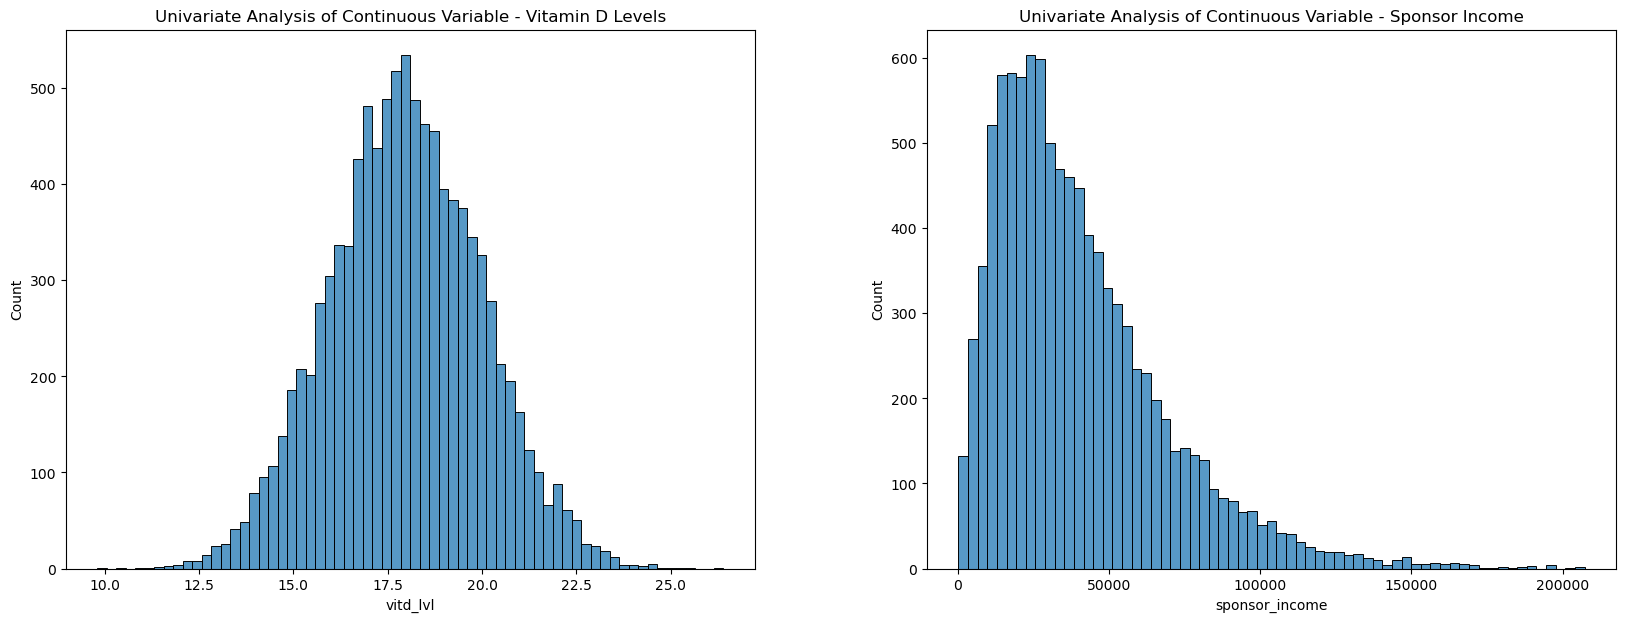

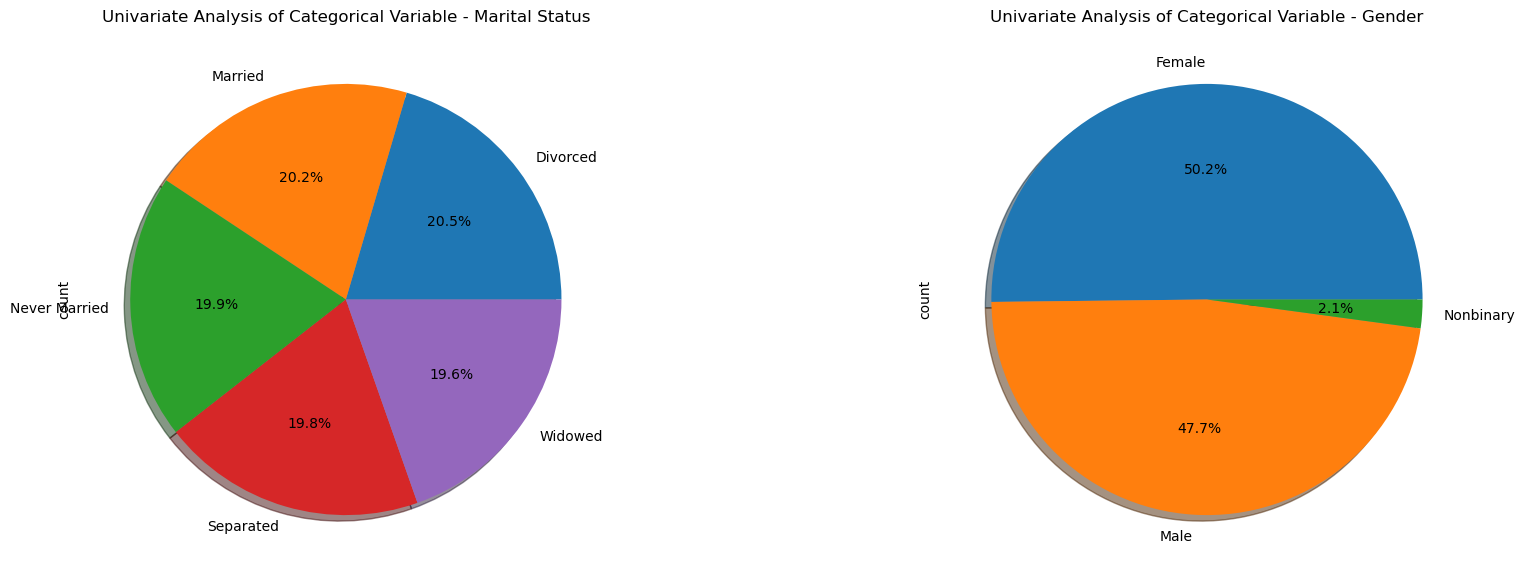

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
  
#Code for plotting univariate analysis of continuous variables in the form of histograms
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

sns.histplot(data=df, x="vitd_lvl", ax=ax[0])
ax[0].title.set_text("Univariate Analysis of Continuous Variable - Vitamin D Levels")

sns.histplot(data=df, x="sponsor_income", ax=ax[1])
ax[1].title.set_text("Univariate Analysis of Continuous Variable - Sponsor Income")

#Code for plotting univariate analysis of categorical variables in the form of pie charts
fig2, ax=plt.subplots(1,2)
fig2.subplots_adjust(hspace=0.125, wspace=0.25)
fig2.set_size_inches(20,7)

counts = df['marital_status'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Divorced', 'Married', 'Never Married', 'Separated', 'Widowed'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Categorical Variable - Marital Status')

counts = df['gender'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Female', 'Male', 'Nonbinary'], shadow=True, ax=ax[1])
ax[1].title.set_text('Univariate Analysis of Categorical Variable - Gender')


I generated two histograms to display the univariate analysis of my continuous variables, vitd_lvl and sponsor_income. The x-axis in these charts represents the class interval while the y-axis shows the corresponding frequency for each of those intervals. 

The first histogram displaying the distribution of vitamin D levels shows a fairly normal distribution, indicating that the data is evenly distributed across the sample and there aren’t too many outliers. The median, mode, and mean are all centered in this sample. The second histogram showing the distribution of income is strongly right, or positively, skewed, showing that more data points are concentrated on the left side and indicating that the mean is greater than the median and mode ("How to interpret histograms," 2024). 

For my univariate analysis of my categorical variables, marital_status and gender, I opted to use pie charts. These show how the categories are proportioned in each data sample. The first pie chart displaying the distribution across marital_status show that there are fairly even representations from each category, “Married,” “Divorced,” “Widowed,” “Separated,” and “Never Married.” In contrast, the pie chart for gender shows that male and female participants are more or less equally represented, with slightly less males than females, but there are very few non-binary entries ("12 univariate data visualizations with illustrations in Python," 2024). 

## D: Bivariate Analysis

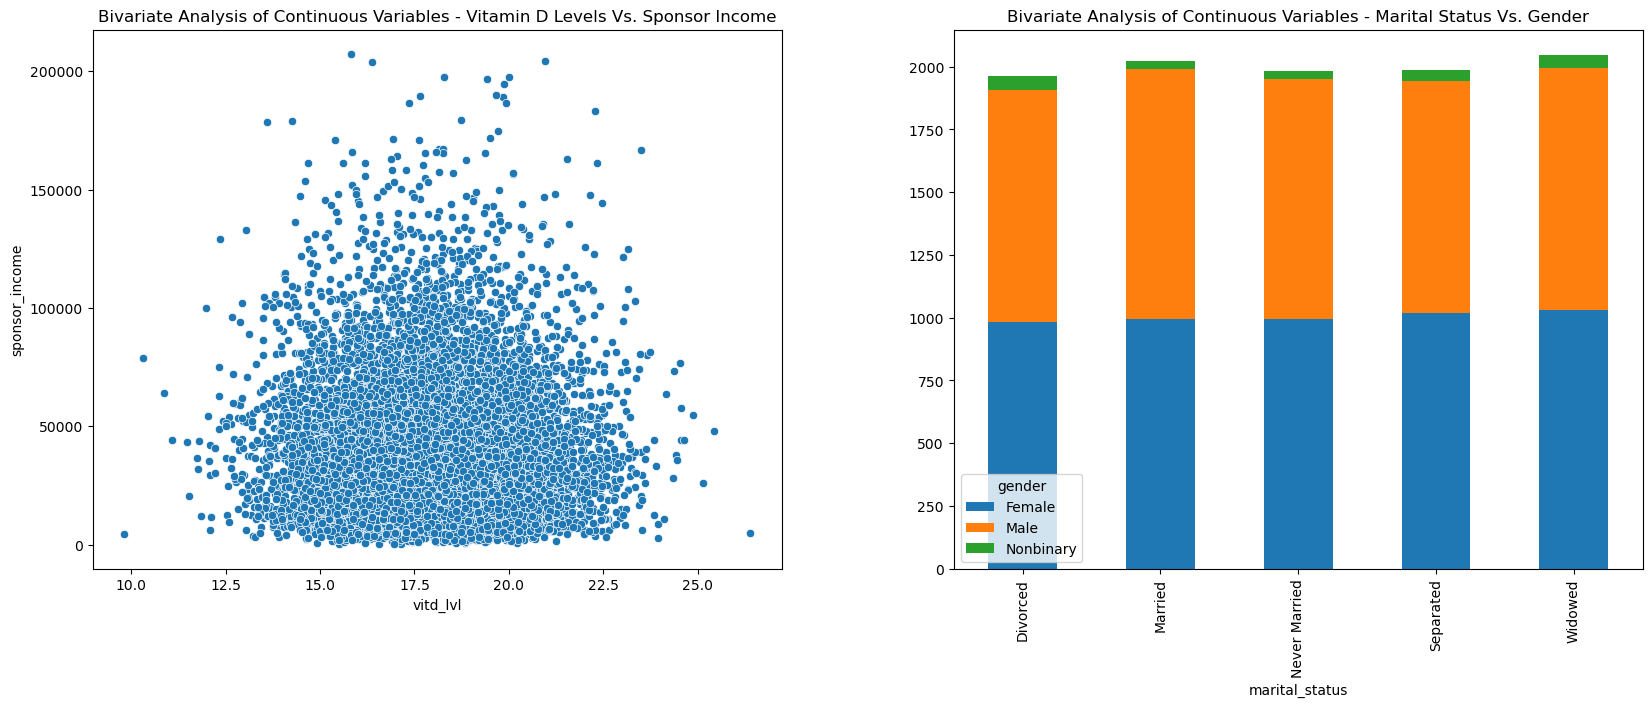

In [7]:
fig, ax=plt.subplots(1,2)
fig.subplots_adjust(hspace=1, wspace=0.25)
fig.set_size_inches(20,7)
sns.scatterplot(data =df, x="vitd_lvl", y="sponsor_income", ax=ax[0])
ax[0].title.set_text("Bivariate Analysis of Continuous Variables - Vitamin D Levels Vs. Sponsor Income")

ct = pd.crosstab(df['marital_status'], df['gender'])
plt = ct.plot(kind='bar', stacked=True, ax=ax[1])
ax[1].title.set_text("Bivariate Analysis of Continuous Variables - Marital Status Vs. Gender")


I again used my variables from my univariate analysis but now compared them to each other in a bivariate analysis using appropriate visualizations. 

For my continuous variables, vitamin D levels and sponsor income, I generate a scatter plot to display how sponsor income varies across different patients with different vitamin D levels. The data was fairly concentrated, showing that most patients had an average income between about $10,000 and $80,000 and also had vitamin D levels between 15.0 and 22.5. Patients with higher income seemed more likely to have vitamin D levels within the median range, while patients with lower incomes seemed slightly more likely to spread to the lower or upper ends of the spectrum. 

For my categorical variables, marital status and gender, I plotted a stacked bar chart using a crosstab of those two variables. The resulting chart showed that there was, again, a fairly equal distribution of males and females across each marital status category. Men were slightly less likely to be divorced, never married, or separated than women, though one must remember that men also comprised less of the overall data sample than women. As non-binary patients comprised little of the data sample to begin with, they only appeared in the fringes of each marital status category but were nonetheless represented in all five (Donatello & Roualdes, 2023). 

## E1: Results of Hypothesis Test

The chi-square test conducted to test a relationship between readmission and patients who were overweight failed to reject the null hypothesis. In other words, the test did not reveal a statistically significant indication that patients were more or less likely to be admitted if they were overweight. The DoF value of 1 showed that we had enough“freedom”or independent numbers in the data sample to proceed with the test, so we can relatively trust the results of this analysis. The p-value was far above the common standard of 0.05 for significance or alpha level, indicating a low probability of a statistically significant relationship. Correspondingly, the chi-square value came in at about 0.70, rounded up from two decimal points which is far below 3.841, the indicated critical value, as determined by our values for degrees of freedom and significance level. The observed frequencies were relatively close to the expected frequencies under the assumption of independence ("The chi-square test for independence," n.d.). 

<div class="img-block">
    <span>Table showing the corresponding chi-square critical values for different p-values and degrees of freedom.</span>
    <img class="aboutimage" src="chi-square-distribution-table.png" width="500"/>
    <p>Turney, S. (Publisher). (2022). Chi-square distribution table (right-tail probabilities). [Table]. <a href="https://www.scribbr.com/statistics/chi-square-distribution-table/">https://www.scribbr.com/statistics/chi-square-distribution-table</a></p>
<div>  

## E2: Limitations of Data Analysis

Although we had enough degrees of freedom to conduct the chi-square test, we are still operating with a relatively small data sample which is represented by the relatively low value for degrees of freedom. A larger sample size with randomly selected patients would lend more credence to the data analysis and end result (Hayes, 2024). 

## E3: Recommended Course of Action

A larger data sample would help to more conclusively establish a lack of relationship between overweight patients and readmission. Additionally, it would likely be beneficial to consider other potential confounding variables such as gender or sponsor income, as these factors may also affect the relationship. For example, overweight men might be more likely to be readmitted than overweight women, but because they represent a smaller subsection of the data sample it might not appear in our end data analysis. 

## F: Panopto Recording

The Panopto explanation of my code may be found at the following link: https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=846fabe2-d93f-4e57-b1cd-b25a000c8df6

## G: Code References

Chi2_contingency -SciPy v1.14.1 manual. (n.d.). The SciPy Community. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

How to create multiple subplots in Matplotlib in Python? (2024, January 16). GeeksforGeeks. https://www.geeksforgeeks.org/how-to-create-multiple-subplots-in-matplotlib-in-python/

How to plot value counts in pandas. (2024, July 22). GeeksforGeeks. https://www.geeksforgeeks.org/how-to-plot-value-counts-in-pandas/

Seaborn.histplot-Seaborn 0.13.2 documentation. (n.d.). seaborn. https://seaborn.pydata.org/generated/seaborn.histplot.html

Seaborn.scatterplot- Seaborn 0.13.2 documentation. (n.d.). seaborn. https://seaborn.pydata.org/generated/seaborn.scatterplot.html

Stacked bar chart- Matplotlib 3.10.0 documentation. (n.d.). Matplotlib. https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html


## H: Source References

12 univariate data visualizations with illustrations in Python. (2024, December 9). Analytics Vidhya. https://www.analyticsvidhya.com/blog/2020/07/univariate-analysis-visualization-with-illustrations-in-python/

The chi-square test for independence. (n.d.). Department of Sociology - The University of Utah. https://soc.utah.edu/sociology3112/chi-square.php

Donatello, R., & Roualdes, E. (2023, August 5). 2.4 bivariate visualizations. norcalbiostat.com. https://norcalbiostat.github.io/AppliedStatistics_notes/bivariate-visualizations.html

Hayes, A. (2024, July 30). CHI-square (χ2) statistic: What it is, examples, how and when to use the test. Investopedia. https://www.investopedia.com/terms/c/chi-square-statistic.asp

How to interpret histograms. (2024, August 16). LabXchange. https://www.labxchange.org/library/items/lb:LabXchange:10d3270e:html:1

Kwak, S. (2023). Are only p-values less than 0.05 significant? A <i>p</i>-value greater than 0.05 is also significant! Journal of Lipid and Atherosclerosis, 12(2), 89. https://doi.org/10.12997/jla.2023.12.2.89

McHugh, M. L. (2013). The Chi-square test of independence. Biochemia Medica, 23(2), 143-149. https://pmc.ncbi.nlm.nih.gov/articles/PMC3900058/

Turney, S. (2023, July 7). How to find degrees of freedom | Definition & formula. Scribbr. https://www.scribbr.com/statistics/degrees-of-freedom/

Turney, S. (2023, June 21). Chi-square distribution table (right-tail probabilities) [Table]. Scribbr. https://www.scribbr.com/statistics/chi-square-distribution-table/

UCLA. (n.d.). What statistical analysis should I use? Statistical analyses using SPSS. OARC Stats – Statistical Consulting Web Resources. https://stats.oarc.ucla.edu/spss/whatstat/what-statistical-analysis-should-i-usestatistical-analyses-using-spss/#:~:text=A%20chi%2Dsquare%20test%20is,relationship%20between%20two%20categorical%20variables

The University of Utah. (n.d.). The chi-square test for independence. Department of Sociology - The University of Utah. https://soc.utah.edu/sociology3112/chi-square.php
